#### Pengertian Analisis Data

Analisis data adalah proses sistematis yang meliputi inspeksi, pembersihan, transformasi, dan pemodelan data dengan tujuan menemukan informasi yang berguna, menarik kesimpulan, dan mendukung pengambilan keputusan.

Dalam konteks bisnis e-commerce seperti Olist, analisis data berperan krusial dalam Data-Driven Decision Making (DDDM). Artinya, keputusan bisnis tidak lagi diambil berdasarkan intuisi atau tebakan semata, melainkan berdasarkan fakta historis yang valid. Contoh penerapannya adalah mengidentifikasi produk terlaris untuk stok ulang atau menemukan wilayah dengan masalah pengiriman tertinggi untuk perbaikan logistik.

#### Perbedaan Descriptive Analysis dan Exploratory Data Analysis (EDA)

Seringkali kedua istilah ini dianggap sama, namun memiliki fokus yang berbeda:

1. Descriptive Analysis (Analisis Deskriptif):

    - Fokus: Menjawab pertanyaan "Apa yang telah terjadi?"

    - Metode: Menggunakan statistik dasar seperti Mean (rata-rata), Median, Modus, dan Standar Deviasi.

    - Contoh: Menghitung total omzet tahun 2017, rata-rata waktu pengiriman, atau jumlah pelanggan aktif.

2. Exploratory Data Analysis (EDA):

    - Fokus: Menjawab pertanyaan "Mengapa ini terjadi?" atau "Adakah pola tersembunyi?"

    - Metode: Menggunakan visualisasi mendalam, mencari korelasi antar variabel, mendeteksi outlier (pencilan), dan menguji hipotesis awal.

    - Contoh: Mencari hubungan antara berat produk dengan biaya ongkir, atau melihat apakah ulasan buruk berkorelasi dengan keterlambatan pengiriman.

#### Urgensi Data Cleaning dan Data Wrangling

Data dunia nyata (seperti dataset Olist ini) jarang sekali bersih. Proses ini adalah fondasi dari analisis yang valid:

1. Data Cleaning: Proses mendeteksi dan memperbaiki (atau menghapus) catatan yang korup, tidak akurat, atau tidak lengkap.

    - Penerapan: Menangani missing values pada kolom tanggal pengiriman (yang mungkin berarti barang hilang), atau menghapus duplikasi data transaksi.

2. Data Wrangling: Proses mengubah format data mentah ke dalam format yang lebih sesuai untuk analisis.

    - Penerapan: Menggabungkan (merge) 9 tabel terpisah Olist menjadi satu kesatuan dataset master, atau mengekstrak fitur "Hari" dan "Bulan" dari kolom timestamp.

3. Konsekuensi: Tanpa tahap ini, analisis akan mengalami prinsip Garbage In, Garbage Out (Masukan sampah akan menghasilkan keluaran sampah/bias).

#### Peran Visualisasi Data

Visualisasi data adalah representasi grafis dari informasi dan data. Tujuannya bukan sekadar mempercantik laporan, tetapi untuk:

- Efisiensi Kognitif: Otak manusia memproses gambar 60.000 kali lebih cepat daripada teks atau tabel angka.

- Identifikasi Pola: Tren musiman atau anomali data lebih mudah terlihat melalui grafik garis atau scatter plot daripada melihat ribuan baris Excel.

- Storytelling: Membantu menyampaikan insight kepada stakeholder non-teknis secara persuasif.

##### Pendekatan Machine Learning: RFM Analysis & Clustering (Opsional)
Dalam proyek ini, teknik analisis lanjutan yang dapat diterapkan adalah RFM Analysis yang terkadang dikombinasikan dengan K-Means Clustering.

- RFM Analysis adalah metode pemasaran untuk mengevaluasi nilai pelanggan berdasarkan tiga metrik:

    - Recency (R): Seberapa baru pelanggan melakukan transaksi terakhir?

    - Frequency (F): Seberapa sering pelanggan bertransaksi?

    - Monetary (M): Berapa total uang yang dikeluarkan pelanggan?

- Tujuan: Mengelompokkan pelanggan ke dalam segmen perilaku (misalnya: Loyal Customers, Big Spenders, atau Lost Customers). Segmentasi ini memungkinkan strategi pemasaran yang lebih personal dan efektif.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# konfigurasi visualisasi
sns.set(style='darkgrid')
plt.style.use('seaborn-v0_8-pastel')

In [5]:
orders_df = pd.read_csv('data/olist_orders_dataset.csv')
items_df = pd.read_csv('data/olist_order_items_dataset.csv')
products_df = pd.read_csv('data/olist_products_dataset.csv')
payments_df = pd.read_csv('data/olist_order_payments_dataset.csv')
reviews_df = pd.read_csv('data/olist_order_reviews_dataset.csv')
customers_df = pd.read_csv('data/olist_customers_dataset.csv')

print("done bang")

done bang


In [ ]:
# gabungkan orders dengan Items (One-to-Many)
merged_df = pd.merge(orders_df, items_df, on='order_id', how='left')

# gabungkan dengan products untuk dapat nama kategori
merged_df = pd.merge(merged_df, products_df, on='product_id', how='left')

# gabungkan dengan payments untuk info pembayaran
merged_df = pd.merge(merged_df, payments_df, on='order_id', how='left')

# gabungkan dengan reviews untuk skor kepuasan
merged_df = pd.merge(merged_df, reviews_df, on='order_id', how='left')

# gabungkan dengan customers untuk data lokasi
merged_df = pd.merge(merged_df, customers_df, on='customer_id', how='left')

print(f"Dimensi Dataframe Gabungan: {merged_df.shape}")
merged_df.head()

Dimensi Dataframe Gabungan: (119143, 36)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


In [ ]:
# mengubah tipe data tanggal
date_columns = ['order_purchase_timestamp', 'order_approved_at', 
                'order_delivered_carrier_date', 'order_delivered_customer_date', 
                'order_estimated_delivery_date']

for col in date_columns:
    merged_df[col] = pd.to_datetime(merged_df[col])

# menangani missing values
# kita hanya akan mengambil order yang statusnya 'delivered' agar analisis valid
clean_df = merged_df[merged_df['order_status'] == 'delivered'].copy()

# hapus baris jika product_category_name kosong (tidak bisa dianalisis kategorinya)
clean_df.dropna(subset=['product_category_name'], inplace=True)

# cek duplikasi
print(f"Jumlah duplikasi: {clean_df.duplicated().sum()}")
clean_df.drop_duplicates(inplace=True)

print(f"Data bersih siap pakai: {clean_df.shape}")

Jumlah duplikasi: 0
Data bersih siap pakai: (114085, 36)


C:\Users\User\AppData\Local\Temp\ipykernel_3428\837042928.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='price', y='product_category_name', data=category_revenue.head(10), palette='viridis')


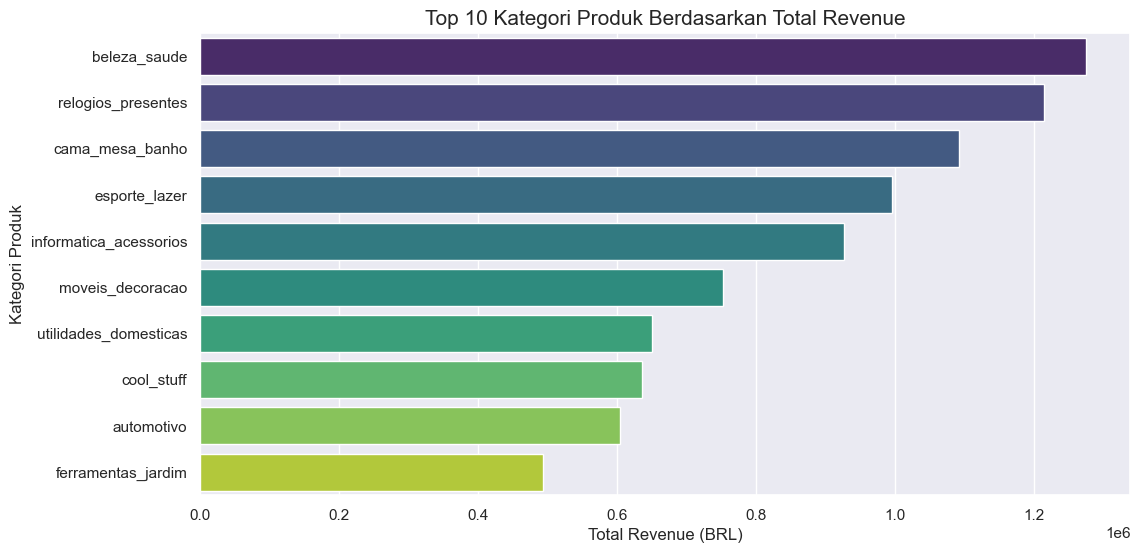

In [ ]:
# grouping berdasarkan kategori dan menjumlahkan harga
category_revenue = clean_df.groupby('product_category_name')['price'].sum().sort_values(ascending=False).reset_index()

# visualisasi 1: bar chart Top 10 Kategori
plt.figure(figsize=(12, 6))
sns.barplot(x='price', y='product_category_name', data=category_revenue.head(10), palette='viridis')
plt.title('Top 10 Kategori Produk Berdasarkan Total Revenue', fontsize=15)
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Kategori Produk')
plt.show()

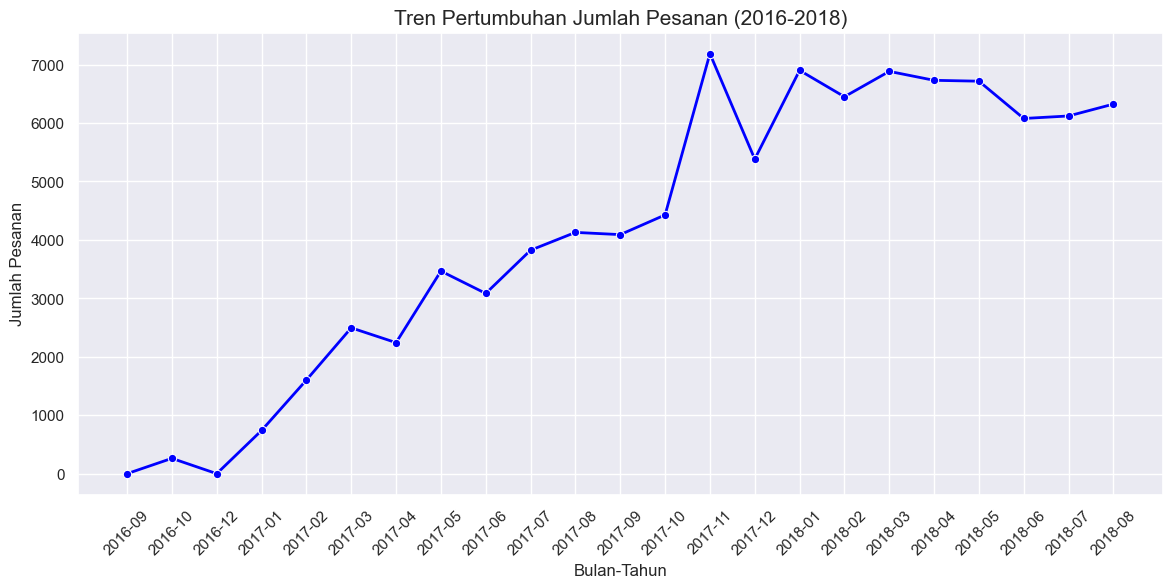

In [ ]:
# ekstrak bulan dan tahun dari timestamp pembelian
clean_df['month_year'] = clean_df['order_purchase_timestamp'].dt.to_period('M')

# hitung jumlah order unik per bulan
monthly_orders = clean_df.groupby('month_year')['order_id'].nunique().reset_index()
monthly_orders['month_year'] = monthly_orders['month_year'].astype(str)

# visualisasi 2: line chart tren bulanan
plt.figure(figsize=(14, 6))
sns.lineplot(x='month_year', y='order_id', data=monthly_orders, marker='o', linewidth=2, color='blue')
plt.title('Tren Pertumbuhan Jumlah Pesanan (2016-2018)', fontsize=15)
plt.xticks(rotation=45)
plt.xlabel('Bulan-Tahun')
plt.ylabel('Jumlah Pesanan')
plt.grid(True)
plt.show()

Sampel Hasil Segmentasi Pelanggan:


,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4,1,1,411
2,0000f46a3911fa3c0805444483337064,537,1,69.00,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,2,1,4,214


C:\Users\User\AppData\Local\Temp\ipykernel_3428\2926631700.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='r_score', data=rfm, palette='coolwarm')


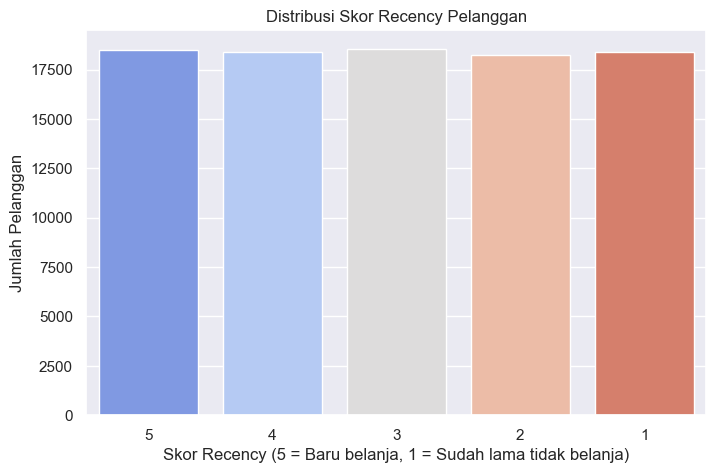

In [ ]:
# menyiapkan data untuk RFM
# tentukan tanggal snapshot (misal: 1 hari setelah transaksi terakhir di dataset)
recent_date = clean_df['order_purchase_timestamp'].max() + pd.to_timedelta(1, unit='D')

# hitung R, F, M per Customer Unique ID
rfm = clean_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (recent_date - x.max()).days, # Recency
    'order_id': 'nunique', # Frequency
    'price': 'sum' # Monetary
}).reset_index()

rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

# implementasi clustering sederhana (Binning dengan qcut)
# kita bagi menjadi skor 1-5 (5 adalah terbaik)
rfm['r_score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1]) # Recency: makin kecil hari makin bagus (skor tinggi)

# karena banyak customer yang beli cuma 1x, qcut mungkin error untuk frequency. kita pakai cut manual atau rank.
# disini kita pakai rank method='first' untuk menangani ties
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['m_score'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5])

# gabungkan skor (RFM Score)
rfm['rfm_segment'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

print("Sampel Hasil Segmentasi Pelanggan:")
display(rfm.head())

# visualisasi Distribusi Segmentasi (berdasarkan Recency Score)
plt.figure(figsize=(8, 5))
sns.countplot(x='r_score', data=rfm, palette='coolwarm')
plt.title('Distribusi Skor Recency Pelanggan')
plt.xlabel('Skor Recency (5 = Baru belanja, 1 = Sudah lama tidak belanja)')
plt.ylabel('Jumlah Pelanggan')
plt.show()

#### Interpretasi Model ML:
- Tujuan dari model ini adalah Mengelompokkan pelanggan untuk strategi marketing.

- Hasil dari model ini adalah skor RFM untuk setiap pelanggan. Pelanggan dengan skor "555" adalah pelanggan terbaik (Baru saja belanja, sering belanja, dan keluar uang banyak). Pelanggan "111" adalah pelanggan yang berisiko hilang (churn).

#### Insight & Kesimpulan

1. Insight Utama
    - Dominasi Kategori: Kategori seperti Bed Bath Table, Health Beauty, dan Sports Leisure mendominasi pendapatan. Fokus stok barang bisa diarahkan ke kategori ini.
    - Tren Penjualan: Terdapat tren kenaikan yang signifikan terutama mendekati akhir tahun (kemungkinan Black Friday di bulan November). Penurunan drastis di akhir grafik kemungkinan karena data 2018 belum lengkap di dataset, bukan penurunan performa bisnis.
    - Perilaku Pelanggan (RFM): Sebagian besar pelanggan Olist adalah pelanggan yang hanya bertransaksi satu kali (one-time buyers), terlihat dari distribusi Frequency yang condong rendah.

2. Kesimpulan
Analisis menunjukkan bahwa Olist memiliki pertumbuhan transaksi yang positif. Namun, tantangan utamanya adalah retensi pelanggan. Karena mayoritas pelanggan hanya berbelanja sekali, perusahaan perlu menerapkan strategi loyalty program atau penawaran khusus bagi pelanggan dengan skor Recency rendah (skor 4 atau 5) agar mereka mau berbelanja kembali (meningkatkan Frequency).